In [13]:
import torch
import time
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import OneClassSVM
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

In [14]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [15]:
df = pd.read_csv('smaller_dataset.csv')

**Preprocessing**

In [ ]:
def create_anomaly_label(row):
    if row['Attack_Type'] == 'Benign&Bruteforce_benign':
        return 'Normal'
    else:
        return 'Attack'



def preprocess(df):
    """
    Engineer features and preprocess data
    """

    df['Anomaly_Label'] = df.apply(create_anomaly_label, axis=1)

    df["Weight"] = df["Total Fwd Packet"] * df["Total Bwd packets"]

    categorical_columns = ["Src IP", 'Dst IP', "Src Port", "Dst Port", "Protocol"]

    for col in categorical_columns:
        df[col] = df[col].astype('category')

    
    for col in ['Src IP', 'Dst IP', 'Src Port', 'Dst Port']:
         df[col + '_freq'] = df[col].map(df[col].value_counts())

    df = pd.get_dummies(df, columns=['Protocol'], prefix='Proto')

    df['Timestamp'] = pd.to_datetime(df['Timestamp'],  format='%d/%m/%Y %I:%M:%S %p')

    attacks_to_remove = [
    "spoofing_ARP Spoofing",
    "spoofing_DNS Spoofing",
    "sqlinjection",
    "XSS",
    "Uploading_Attack"  ]

    df = df[~df["Attack_Type"].isin(attacks_to_remove)]
    

    df['Flow_Duration'] = df['Flow Duration'] / 1_000_000

    # Replace any 0 to avoid division by zero
    df['Flow_Duration'] = df['Flow_Duration'].replace(0, 1e-6)
        
    # === DDoS Detection Features ===
    
    # 2. Flow asymmetry indicators (DDoS often has imbalanced flows)
    df['Fwd_Bwd_Packet_Ratio'] = df['Total Fwd Packet'] / (df['Total Bwd packets'] + 1)
    df['Fwd_Bwd_Bytes_Ratio'] = df['Total Length of Fwd Packet'] / (df['Total Length of Bwd Packet'] + 1)
    
    # 3. Packet size anomalies
    df['Avg_Fwd_Packet_Size'] = df['Total Length of Fwd Packet'] / (df['Total Fwd Packet'] + 1)
    df['Packet_Size_Variance_Ratio'] = df['Packet Length Variance'] / (df['Flow Bytes/s'] + 1)
    
    # === Protocol-Specific Features ===
    
    # 4. ICMP Flood Detection (Proto_17 = 1 indicates ICMP)
    df['ICMP_Flood_Score'] = (
        df['Proto_17'] * 
        df['Fwd Packets/s'] * 
        (df['Total Fwd Packet'] > df['Total Fwd Packet'].quantile(0.8)).astype(int)
    )
    
    # 5. TCP-based DDoS indicators (Proto_6 = 1 indicates TCP)
    df['TCP_Flood_Score'] = (
        df['Proto_6'] * 
        df['Fwd Packets/s'] * 
        (df['SYN Flag Count'] + df['RST Flag Count'] + df['FIN Flag Count'])
    )
    
    # 6. HTTP Flood Detection (common web ports + high packet rate)
    http_port_mask = (
        (df['Dst Port'] == 80) | 
        (df['Dst Port'] == 443) | 
        (df['Dst Port'] == 8080) | 
        (df['Dst Port'] == 8443)
    )
    df['HTTP_Flood_Score'] = (
        http_port_mask.astype(int) * 
        df['Fwd Packets/s'] * 
        (df['PSH Flag Count'] + df['Fwd PSH Flags'] + df['Bwd PSH Flags'])
    )
    
    # === Vulnerability Scan Detection ===
    
    # 7. Port scanning indicators using existing frequency features
    df['Port_Scan_Score'] = (
        df['Dst Port_freq'] *  # High destination port diversity
        df['Src IP_freq'] *    # From same source IP
        (df['Total Fwd Packet'] < df['Total Fwd Packet'].quantile(0.5)).astype(int)  # Small packets
    )
    
    # 8. Network scanning behavior
    df['Network_Scan_Score'] = (
        df['Dst IP_freq'] *    # High destination IP diversity
        df['Src IP_freq'] *    # From same source
        (df['SYN Flag Count'] > 0).astype(int) *  # TCP SYN packets
        (df['Total Length of Bwd Packet'] == 0).astype(int)  # No response packets
    )
    
    # === Advanced DDoS Features ===
    
    # 9. Inter-arrival time anomalies (consistent timing in DDoS)
    df['IAT_Consistency'] = np.where(
        df['Fwd IAT Std'] > 0,
        df['Fwd IAT Mean'] / df['Fwd IAT Std'],
        0
    )
    
    # === Combined Attack Indicators ===
    
    # 13. Multi-feature DDoS score
    df['DDoS_Combined_Score'] = (
        df['Fwd Packets/s'] * 0.3 +
        df['ICMP_Flood_Score'] * 0.2 +
        df['TCP_Flood_Score'] * 0.2 +
        df['HTTP_Flood_Score'] * 0.2 +
        df['IAT_Consistency'] * 0.1
    )
    
    # 14. Vulnerability scan combined score
    df['Scan_Combined_Score'] = (
        df['Port_Scan_Score'] * 0.4 +
        df['Network_Scan_Score'] * 0.4 +
        (df['Dst Port_freq'] * df['Dst IP_freq']) * 0.2
    )
    
    # === Statistical Anomaly Features ===
    
    # 16. Flag usage anomalies
    df['Flag_Usage_Score'] = (
        df['SYN Flag Count'] + 
        df['RST Flag Count'] + 
        df['FIN Flag Count'] + 
        df['PSH Flag Count'] + 
        df['URG Flag Count']
    ) / (df['Total Fwd Packet'] + 1)
    
    # 17. Subflow anomalies
    df['Subflow_Anomaly'] = np.abs(
        df['Subflow Fwd Bytes'] - df['Subflow Bwd Bytes']
    ) / (df['Flow Bytes/s'] + 1)
    
    # === Target Attack Specific Features ===
    
    # Create specific indicators for each target attack type
    attack_indicators = {}
    
    # DDoS-HTTP Flood specific
    attack_indicators['DDoS_HTTP_Indicator'] = (
        df['HTTP_Flood_Score'] * 
        (df['Proto_6'] == 1).astype(int) *  # TCP protocol
        (df['Fwd Packets/s'] > df['Fwd Packets/s'].quantile(0.9)).astype(int)
    )
    
    # DDoS-ICMP Flood specific  
    attack_indicators['DDoS_ICMP_Indicator'] = (
        df['ICMP_Flood_Score'] *
        (df['Bwd Packet Length Min'] == 0).astype(int) *  # Often no response
        (df['Fwd Packets/s'] > df['Fwd Packets/s'].quantile(0.8)).astype(int)
    )
    
    # DDoS-ICMP Fragmentation specific
    attack_indicators['DDoS_ICMP_Frag_Indicator'] = (
        df['Proto_17'] *  # ICMP
        (df['Packet Length Variance'] > df['Packet Length Variance'].quantile(0.7)).astype(int) *
        df['Fwd Packets/s']
    )
    
    # Vulnerability Scan specific
    attack_indicators['VulnScan_Indicator'] = (
        df['Scan_Combined_Score'] *
        (df['Active Min'] > 0).astype(int) *  # Active probing
        (df['Total Length of Bwd Packet'] < df['Total Length of Fwd Packet']).astype(int)
    )
    
    # Add all indicators to dataframe
    for indicator_name, indicator_values in attack_indicators.items():
        df[indicator_name] = indicator_values


    columns_to_drop = ["Flow IAT Std",
                   "Bwd Segment Size Avg",
                   "Subflow Fwd Packets",
    'Flow Duration',
    'Subflow Bwd Packets',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Flow Packets/s',
    'Flow IAT Min',
    'Flow IAT Max',
    'Bwd IAT Max',
    'Bwd IAT Min',
    'Fwd Header Length',
    'ACK Flag Count',
    'Packet Length Std',
    "Fwd IAT Max",
    "Idle Max",
    "Idle Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    'Average Packet Size',
    'Fwd Segment Size Avg',
    'Fwd IAT Max',
    'Bwd Header Length',
    'Packet Length Mean',
    'CWR Flag Count',
    'Average Packet Size',
    "Flow IAT Mean",
    "Active Max",
    "Bwd Bytes/Bulk Avg",
    'Fwd IAT Mean',
    'Active Mean',
    'Active Std',
    "Fwd Act Data Pkts",
    "Flow_Duration",
    "ICMP_Flood_Score",
    "HTTP_Flood_Score",
    "Port_Scan_Score",
    "IAT_Consistency" ,
    "DDoS_Combined_Score"
]

    df = df.drop(columns=columns_to_drop)
    df = df.drop(columns="Label")


    null_columns = df.isnull().sum()
    null_columns = null_columns[null_columns > 0]
    df = df.dropna()
    df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    
        
    return df

In [17]:
df = preprocess(df)

***Begin preparation for the model***

In [18]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, activation=nn.ReLU(), dropout_rate=0.0,
                 sequence_length=1, num_layers=1, bidirectional=False):
        super(LSTMAutoencoder, self).__init__()

        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.bottleneck_dim = hidden_dims[-1]
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.directions = 2 if bidirectional else 1
        self.activation = activation

        # Encoder 
        self.encoder_layers = nn.ModuleList()
        prev_dim = input_dim
        for h_dim in hidden_dims:
            self.encoder_layers.append(nn.LSTM(
                input_size=prev_dim,
                hidden_size=h_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=bidirectional
            ))
            prev_dim = h_dim * self.directions

        # Decoder 
        self.decoder_layers = nn.ModuleList()
        reversed_dims = list(reversed(hidden_dims))
        prev_dim = reversed_dims[0] * self.directions  # bottleneck dimension

        # Create decoder layers
        for i in range(len(reversed_dims) - 1):
            next_dim = reversed_dims[i+1]
            self.decoder_layers.append(nn.LSTM(
                input_size=prev_dim,
                hidden_size=next_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=bidirectional
            ))
            prev_dim = next_dim * self.directions

        # Final output layer
        self.output_layer = nn.Linear(hidden_dims[0] * self.directions, input_dim)

        # Dropout layer
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

    def forward(self, x):
        # Handle 2D input (reshape to add sequence dimension if needed)
        original_shape = x.shape
        if len(x.shape) == 2:
            x = x.unsqueeze(1)  # [batch_size, 1, input_dim]

        batch_size = x.size(0)
        seq_len = x.size(1)

        # Encode
        current_input = x
        for i, encoder in enumerate(self.encoder_layers):
            outputs, (hidden, cell) = encoder(current_input)
            current_input = outputs

            # Apply activation
            if self.activation is not None:
                current_input = self.activation(current_input)

            # Apply dropout except for last layer
            if self.dropout is not None and i < len(self.encoder_layers) - 1:
                current_input = self.dropout(current_input)

        # Get encoded representation (last time step of final encoder output)
        encoded = outputs[:, -1, :]

        # Initialize decoder input with encoded representation
        decoder_input = encoded.unsqueeze(1).repeat(1, seq_len, 1)

        # Decode
        current_input = decoder_input
        for i, decoder in enumerate(self.decoder_layers):
            outputs, _ = decoder(current_input)
            current_input = outputs

            # Apply activation except for last layer
            if self.activation is not None and i < len(self.decoder_layers) - 1:
                current_input = self.activation(current_input)

            # Apply dropout except for last layer
            if self.dropout is not None and i < len(self.decoder_layers) - 1:
                current_input = self.dropout(current_input)

        # Final projection
        reconstructed = self.output_layer(current_input)

        # Return to original shape if needed
        if len(original_shape) == 2:
            reconstructed = reconstructed.squeeze(1)

        return reconstructed, encoded

**Seperate training and test data**

In [ ]:
X = df.select_dtypes(include=['number', 'bool'])
X_datetime = df.select_dtypes(include=['datetime64'])

attack_types = df['Attack_Type']  
y = df['Anomaly_Label']  
y_binary = (y == "Attack").astype(int)  


df_temp = df.copy()
df_temp['stratify_col'] = df_temp['Attack_Type']  


df_temp.loc[df_temp['Anomaly_Label'] == 'Normal', 'stratify_col'] = 'Normal'

print("Original Attack Type Distribution:")
print(df_temp['stratify_col'].value_counts())
print(f"\nOriginal Attack/Normal Distribution:")
print(df_temp['Anomaly_Label'].value_counts())


np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


for col in X_datetime.columns:
    X_datetime[col] = pd.to_datetime(X_datetime[col]).astype('int64') // 10**9

# Scale numerical and boolean features
scaler_numerical = StandardScaler()
X_scaled_num = scaler_numerical.fit_transform(X)

# Scale datetime features
scaler_datetime = StandardScaler()
X_scaled_datetime = scaler_datetime.fit_transform(X_datetime)

# Combine scaled features into a single NumPy array
X_scaled = np.concatenate([X_scaled_num, X_scaled_datetime], axis=1)
print("Had ", X_scaled.shape[1] ,"features")

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_scaled = pca.fit_transform(X_scaled)


print("Components after reduction: ", pca.n_components_)  # number of components after reduction



try:
    X_train_full, X_test, y_train_full, y_test, stratify_train, stratify_test = train_test_split(
        X_scaled, y_binary, df_temp['stratify_col'], 
        test_size=0.3, random_state=42, stratify=df_temp['stratify_col']
    )
    

    original_indices = np.arange(len(X_scaled))
    train_indices, test_indices = train_test_split(
        original_indices, test_size=0.3, random_state=42, stratify=df_temp['stratify_col']
    )

    print("\n=== TRAIN SET DISTRIBUTION ===")
    train_stratify_counts = pd.Series(stratify_train).value_counts()
    print("Attack Type Distribution in Training Set:")
    print(train_stratify_counts)
    print(f"Normal vs Attack in Training Set:")
    print(pd.Series(y_train_full).value_counts())
    
    print("\n=== TEST SET DISTRIBUTION ===")
    test_stratify_counts = pd.Series(stratify_test).value_counts()
    print("Attack Type Distribution in Test Set:")
    print(test_stratify_counts)
    print(f"Normal vs Attack in Test Set:")
    print(pd.Series(y_test).value_counts())
    
except ValueError as e:
    print(f"Stratification failed: {e}")
    print("Some attack types might have too few samples. Using alternative approach...")
    

    from collections import defaultdict
    

    attack_type_indices = defaultdict(list)
    for idx, attack_type in enumerate(df_temp['stratify_col']):
        attack_type_indices[attack_type].append(idx)
    
    train_indices = []
    test_indices = []
    
    for attack_type, indices in attack_type_indices.items():
        if len(indices) == 1:

            train_indices.extend(indices)
        else:
     
            n_test = max(1, int(len(indices) * 0.3))
            np.random.shuffle(indices)
            test_indices.extend(indices[:n_test])
            train_indices.extend(indices[n_test:])
    

    X_train_full = X_scaled[train_indices]
    X_test = X_scaled[test_indices]
    y_train_full = y_binary.iloc[train_indices].values
    y_test = y_binary.iloc[test_indices].values
    stratify_train = df_temp['stratify_col'].iloc[train_indices].values
    stratify_test = df_temp['stratify_col'].iloc[test_indices].values
    


Original Attack Type Distribution:
stratify_col
Normal                          398198
DoS_DoS SYN Flood                24434
DoS_DoS-UDP_Flood                 7812
DDoS_DDoS ACK Fragmentation       3675
DoS_DoS-HTTP_Flood                2331
DDoS_DDoS-HTTP Flood               758
VulnerabilityScan                  661
DDoS_DDoS-ICMP_Fragmentation       481
DDoS_DDoS ICMP Flood               303
Mirai                              262
Benign&Bruteforce_BruteForce         5
Name: count, dtype: int64

Original Attack/Normal Distribution:
Anomaly_Label
Normal    398198
Attack     40722
Name: count, dtype: int64
Using device: cuda
Had  66 features
Components after reduction:  38

=== TRAIN SET DISTRIBUTION ===
Attack Type Distribution in Training Set:
stratify_col
Normal                          278739
DoS_DoS SYN Flood                17104
DoS_DoS-UDP_Flood                 5468
DDoS_DDoS ACK Fragmentation       2572
DoS_DoS-HTTP_Flood                1632
DDoS_DDoS-HTTP Flood               

In [20]:
print("\n=== TRAIN SET DISTRIBUTION (Manual Split) ===")
print("Attack Type Distribution in Training Set:")
print(pd.Series(stratify_train).value_counts())
print(f"Normal vs Attack in Training Set:")
print(pd.Series(y_train_full).value_counts())

print("\n=== TEST SET DISTRIBUTION (Manual Split) ===")
print("Attack Type Distribution in Test Set:")
print(pd.Series(stratify_test).value_counts())
print(f"Normal vs Attack in Test Set:")
print(pd.Series(y_test).value_counts())


=== TRAIN SET DISTRIBUTION (Manual Split) ===
Attack Type Distribution in Training Set:
stratify_col
Normal                          278739
DoS_DoS SYN Flood                17104
DoS_DoS-UDP_Flood                 5468
DDoS_DDoS ACK Fragmentation       2572
DoS_DoS-HTTP_Flood                1632
DDoS_DDoS-HTTP Flood               531
VulnerabilityScan                  463
DDoS_DDoS-ICMP_Fragmentation       337
DDoS_DDoS ICMP Flood               212
Mirai                              183
Benign&Bruteforce_BruteForce         3
Name: count, dtype: int64
Normal vs Attack in Training Set:
Anomaly_Label
0    278739
1     28505
Name: count, dtype: int64

=== TEST SET DISTRIBUTION (Manual Split) ===
Attack Type Distribution in Test Set:
stratify_col
Normal                          119459
DoS_DoS SYN Flood                 7330
DoS_DoS-UDP_Flood                 2344
DDoS_DDoS ACK Fragmentation       1103
DoS_DoS-HTTP_Flood                 699
DDoS_DDoS-HTTP Flood               227
VulnerabilityS

**LSTM BASED AUTOENCODER**

In [ ]:

X_train = X_train_full[y_train_full == 0]

attack_train_mask = (y_train_full == 1)

X_test = np.concatenate([X_test, X_train_full[attack_train_mask]], axis=0)
y_test = np.concatenate([y_test, y_train_full[attack_train_mask]], axis=0)


original_test_indices = test_indices.copy()


attack_train_indices = np.where(y_train_full == 1)[0]

attack_train_original_indices = np.array(train_indices)[attack_train_indices]


test_indices = np.concatenate([original_test_indices, attack_train_original_indices])


print(f"Updated test set size: {len(y_test)}")
print(f"Test indices size: {len(test_indices)}")
assert len(test_indices) == len(y_test), "Array sizes don't match!"


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values if hasattr(y_test, 'values') else y_test, dtype=torch.bool)

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=64, shuffle=True)

Updated test set size: 160181
Test indices size: 160181


In [ ]:
# =======================
# Training and Evaluation for LSTM Autoencoder
# =======================
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


input_dim = X_train.shape[1]
hidden_dims = [24,12]  # Example dimensions, adjust as needed
sequence_length = 5 

model = LSTMAutoencoder(
    input_dim=input_dim,
    hidden_dims=hidden_dims,
    sequence_length=sequence_length,
    num_layers=1,
    bidirectional=True,
    dropout_rate=0.1
).to(device)


# Example forward pass
batch_size = 32
# Reshape inputs for LSTM if necessary (batch_size, sequence_length, features)
x = torch.randn(batch_size, sequence_length, input_dim)
x = x.to(device)


Using device: cuda


In [ ]:
def preprocess_for_threshold_selection(df_threshold, scaler_numerical, scaler_datetime, pca):
    """
    Preprocess the threshold selection dataset using the same transformations
    as the original training data.
    
    Args:
        df_threshold: DataFrame with the threshold selection data
        scaler_numerical: Fitted StandardScaler for numerical features
        scaler_datetime: Fitted StandardScaler for datetime features  
        pca: Fitted PCA transformer
    
    Returns:
        X_threshold_scaled: Preprocessed features
        y_threshold_binary: Binary labels (1 for Attack, 0 for Normal)
    """
  
    X_threshold = df_threshold.select_dtypes(include=['number', 'bool'])
    X_threshold_datetime = df_threshold.select_dtypes(include=['datetime64'])
    

    y_threshold = df_threshold['Anomaly_Label']
    y_threshold_binary = (y_threshold == "Attack").astype(int)
    

    for col in X_threshold_datetime.columns:
        X_threshold_datetime[col] = pd.to_datetime(X_threshold_datetime[col]).astype('int64') // 10**9
    

    X_threshold_scaled_num = scaler_numerical.transform(X_threshold)
    X_threshold_scaled_datetime = scaler_datetime.transform(X_threshold_datetime)
    
 
    X_threshold_combined = np.concatenate([X_threshold_scaled_num, X_threshold_scaled_datetime], axis=1)
    

    X_threshold_scaled = pca.transform(X_threshold_combined)
    
    print(f"Threshold dataset shape after preprocessing: {X_threshold_scaled.shape}")
    print(f"Normal vs Attack distribution in threshold dataset:")
    print(pd.Series(y_threshold_binary).value_counts())
    
    return X_threshold_scaled, y_threshold_binary

Training samples (Normal only): 278,739
Test samples (Normal + Attacks): 160,181
Features: 38
Epoch 1/10, Train Loss: 0.4729, Test Loss: 0.8849
Epoch 2/10, Train Loss: 0.2851, Test Loss: 0.8306
Epoch 3/10, Train Loss: 0.2541, Test Loss: 0.8162
Epoch 4/10, Train Loss: 0.2384, Test Loss: 0.8060
Epoch 5/10, Train Loss: 0.2268, Test Loss: 0.8085
Epoch 6/10, Train Loss: 0.2144, Test Loss: 0.7904
Epoch 7/10, Train Loss: 0.2015, Test Loss: 0.8005
Epoch 8/10, Train Loss: 0.1924, Test Loss: 0.8145
Epoch 9/10, Train Loss: 0.1824, Test Loss: 0.7971
Epoch 10/10, Train Loss: 0.1762, Test Loss: 0.8315

Total Training Time: 376.31 seconds


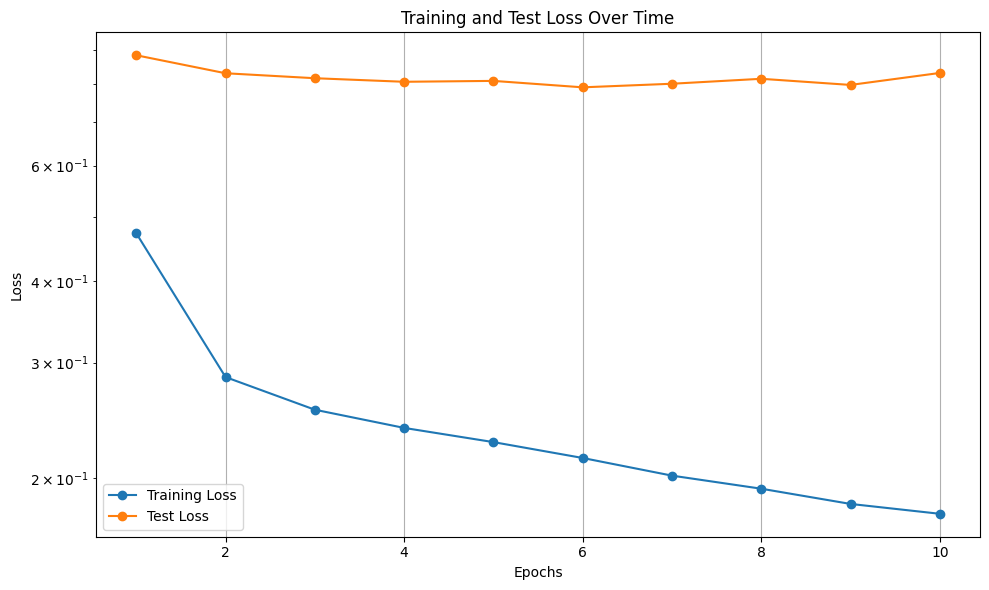

In [ ]:
# Add timing variables
total_train_time = 0
total_test_time = 0

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)


train_losses = []
test_losses = []


n_train_samples = len(X_train)
n_test_samples = len(X_test)
n_features = X_train.shape[1]

print(f"Training samples (Normal only): {n_train_samples:,}")
print(f"Test samples (Normal + Attacks): {n_test_samples:,}")
print(f"Features: {n_features}")

# Training loop
n_epochs = 10
model.train()


total_train_start = time.time()

for epoch in range(n_epochs):
    # Training phase
    model.train()
    epoch_loss = 0

    # Time each epoch
    epoch_start_time = time.time()

    for batch in train_loader:
        inputs = batch[0].to(device)

        if len(inputs.shape) == 2:
            inputs = inputs.unsqueeze(1)  

        outputs, _= model(inputs) 
        loss = criterion(outputs, inputs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_end_time = time.time()
    epoch_train_time = epoch_end_time - epoch_start_time

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)


# Evaluation phase - moved inside the epoch loop
    model.eval()
    with torch.no_grad():
        # Time the test/evaluation phase
        test_start_time = time.time()
        X_test_tensor_for_loss = X_test_tensor.to(device)

        if len(X_test_tensor_for_loss.shape) == 2:
            X_test_tensor_for_loss = X_test_tensor_for_loss.unsqueeze(1)  

        outputs, _ = model(X_test_tensor_for_loss)
        test_loss = criterion(outputs, X_test_tensor_for_loss).item()
        test_losses.append(test_loss)
    
        test_end_time = time.time()
        epoch_test_time = test_end_time - test_start_time

    scheduler.step(avg_train_loss)
    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}")

# End total training time
total_train_end = time.time()
total_train_time = total_train_end - total_train_start
print(f"\nTotal Training Time: {total_train_time:.2f} seconds")

# Plot the training and test loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, n_epochs + 1), test_losses, label='Test Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Time')
plt.legend()
plt.grid(True)
plt.yscale('log')  
plt.tight_layout()
plt.show()


Threshold dataset shape after preprocessing: (442904, 38)
Normal vs Attack distribution in threshold dataset:
Anomaly_Label
0    398198
1     44706
Name: count, dtype: int64
Loading new test dataset: proportional_sample_30pct_size_10pct_attack.csv
Threshold dataset shape after preprocessing: (1217051, 38)
Normal vs Attack distribution in threshold dataset:
Anomaly_Label
1    818853
0    398198
Name: count, dtype: int64
Threshold dataset shape: (442904, 38)
Original test dataset (30%) shape: torch.Size([160181, 38])
New test dataset (20%) shape: (1217051, 38)
Threshold dataset anomaly ratio: 0.1009
Original test dataset anomaly ratio: 0.2542
New test dataset anomaly ratio: 0.6728
Original Test Dataset (30%) Inference Time: 0.0183 seconds
New Test Dataset (20%) Inference Time: 2.6390 seconds
Optimal threshold (from threshold dataset): 0.187347, F1 score: 0.8739

=== RESULTS ON ORIGINAL TEST DATA (30% split) ===
Threshold used: 0.18734711

Classification Report (ORIGINAL TEST DATA - 30% s

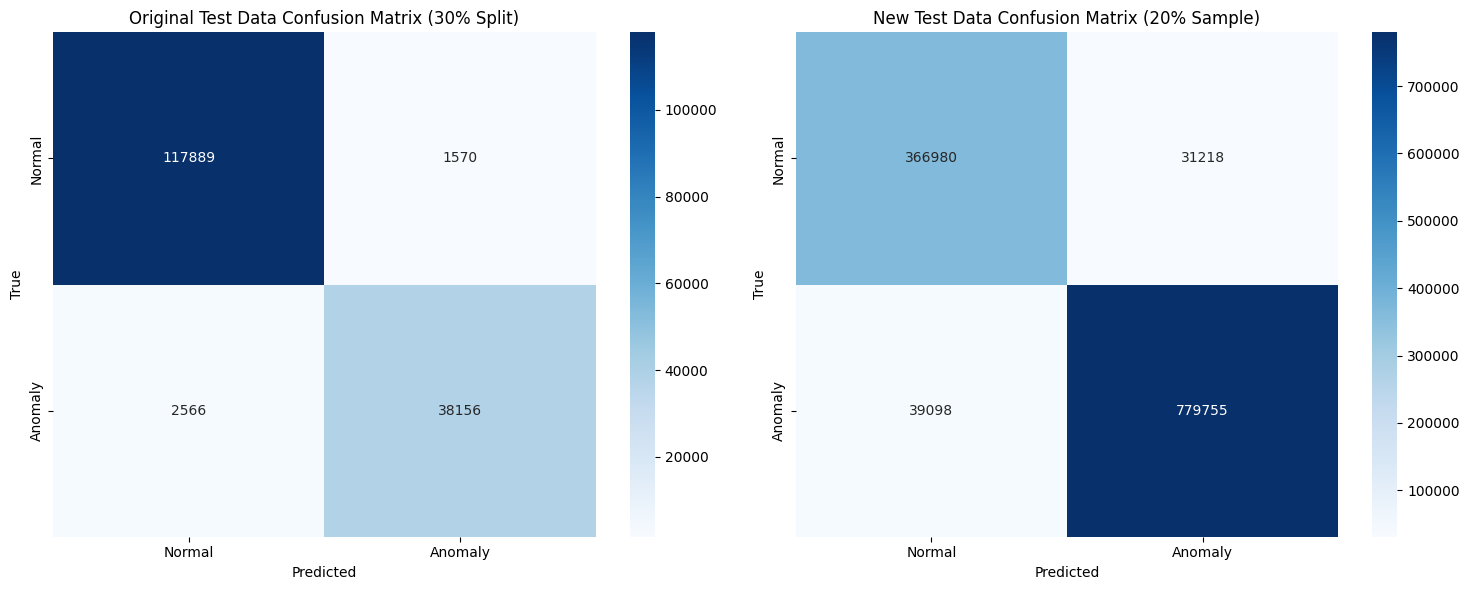

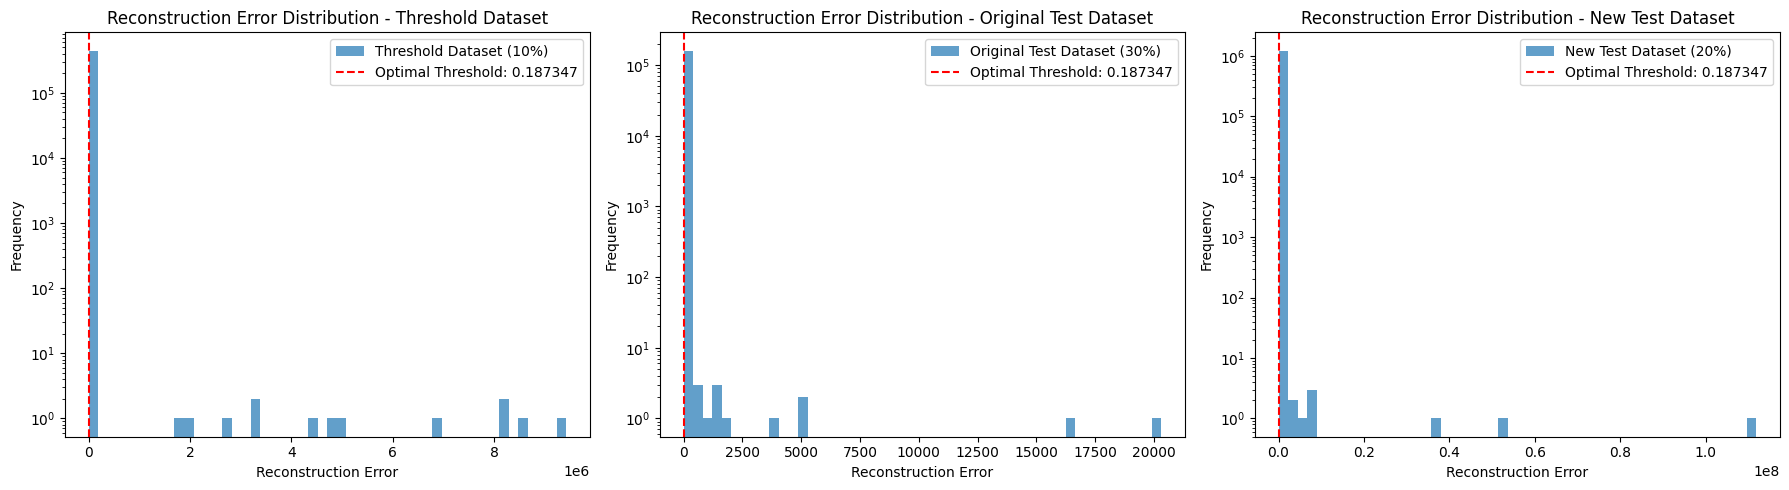


=== SUMMARY TABLE ===
Dataset              Classifier      Train Time (s)  Test Time (s)   Train Samples   Test Samples    Features   Accuracy   Precision    Recall     F1 Score  
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Original (30%)       LSTM-AE         376.31          0.0183          278,739         160,181         38         0.9742     0.9605       0.9370     0.9486    
New CSV (20%)        LSTM-AE         376.31          2.6390          278,739         1,217,051       38         0.9422     0.9615       0.9523     0.9569    

=== DATASET COMPARISON ===
Threshold dataset (10%) - Samples: 442,904, Anomaly ratio: 0.1009
Original test dataset (30%) - Samples: 160,181, Anomaly ratio: 0.2542
New test dataset (20%) - Samples: 1,217,051, Anomaly ratio: 0.6728


In [ ]:

df_threshold = pd.read_csv('augmented_smaller_dataset.csv')
df_threshold = preprocess(df_threshold)


X_threshold_scaled, y_threshold_binary = preprocess_for_threshold_selection(
    df_threshold, scaler_numerical, scaler_datetime, pca
)


X_threshold_tensor = torch.tensor(X_threshold_scaled, dtype=torch.float32)
y_threshold_np = np.array(y_threshold_binary)

# ==========================================
# LOAD NEW TEST DATASET (20% sample)
# ==========================================
print("Loading new test dataset: proportional_sample_30pct_size_10pct_attack.csv")
df_new_test = pd.read_csv('proportional_sample_30pct_size_10pct_attack.csv')
df_new_test = preprocess(df_new_test)


X_new_test_scaled, y_new_test_binary = preprocess_for_threshold_selection(
    df_new_test, scaler_numerical, scaler_datetime, pca
)

# Convert to tensor for model inference
X_new_test_tensor = torch.tensor(X_new_test_scaled, dtype=torch.float32)
y_new_test_np = np.array(y_new_test_binary)

print(f"Threshold dataset shape: {X_threshold_scaled.shape}")
print(f"Original test dataset (30%) shape: {X_test_tensor.shape}")
print(f"New test dataset (20%) shape: {X_new_test_scaled.shape}")
print(f"Threshold dataset anomaly ratio: {np.mean(y_threshold_np):.4f}")
print(f"Original test dataset anomaly ratio: {torch.mean(y_test_tensor.float()):.4f}")
print(f"New test dataset anomaly ratio: {np.mean(y_new_test_np):.4f}")

# ==========================================
# STEP 1: Get reconstruction errors for THRESHOLD DATASET
# ==========================================
model.eval()
with torch.no_grad():
    X_threshold_tensor = X_threshold_tensor.to(device)
    
    # Reshape for LSTM if necessary
    if len(X_threshold_tensor.shape) == 2:
        X_threshold_tensor = X_threshold_tensor.unsqueeze(1) 
    
    reconstructions_threshold, _ = model(X_threshold_tensor) 
    
    # Calculate reconstruction error for THRESHOLD dataset
    if len(X_threshold_tensor.shape) == 3:
   
        reconstruction_error_threshold = torch.mean((X_threshold_tensor - reconstructions_threshold) ** 2, dim=(1, 2)).cpu().numpy()
    else:
      
        reconstruction_error_threshold = torch.mean((X_threshold_tensor - reconstructions_threshold) ** 2, dim=1).cpu().numpy()

# ==========================================
# STEP 2: Get reconstruction errors for ORIGINAL TEST DATASET (30%)
# ==========================================
with torch.no_grad():
    inference_start_time = time.time()
    X_original_test_for_inference = X_test_tensor.to(device)
    

    if len(X_original_test_for_inference.shape) == 2:
        X_original_test_for_inference = X_original_test_for_inference.unsqueeze(1)  # Add sequence dimension
    
    reconstructions_original_test, _ = model(X_original_test_for_inference)  # Get reconstructions for ORIGINAL TEST data
    
    # Calculate reconstruction error for ORIGINAL TEST dataset
    if len(X_original_test_for_inference.shape) == 3:
       
        reconstruction_error_original_test = torch.mean((X_original_test_for_inference - reconstructions_original_test) ** 2, dim=(1, 2)).cpu().numpy()
    else:
     
        reconstruction_error_original_test = torch.mean((X_original_test_for_inference - reconstructions_original_test) ** 2, dim=1).cpu().numpy()
    
    inference_time_original = time.time() - inference_start_time

# ==========================================
# STEP 3: Get reconstruction errors for NEW TEST DATASET (20%)
# ==========================================
with torch.no_grad():
    inference_start_time = time.time()
    X_new_test_tensor_for_inference = X_new_test_tensor.to(device)
    
 
    if len(X_new_test_tensor_for_inference.shape) == 2:
        X_new_test_tensor_for_inference = X_new_test_tensor_for_inference.unsqueeze(1)  # Add sequence dimension
    
    reconstructions_new_test, _ = model(X_new_test_tensor_for_inference)  # Get reconstructions for NEW TEST data
    

    if len(X_new_test_tensor_for_inference.shape) == 3:
        
        reconstruction_error_new_test = torch.mean((X_new_test_tensor_for_inference - reconstructions_new_test) ** 2, dim=(1, 2)).cpu().numpy()
    else:
        
        reconstruction_error_new_test = torch.mean((X_new_test_tensor_for_inference - reconstructions_new_test) ** 2, dim=1).cpu().numpy()
    
    inference_time_new = time.time() - inference_start_time

print(f"Original Test Dataset (30%) Inference Time: {inference_time_original:.4f} seconds")
print(f"New Test Dataset (20%) Inference Time: {inference_time_new:.4f} seconds")

# ==========================================
# STEP 4: Find optimal threshold using THRESHOLD dataset
# ==========================================
best_f1 = 0
best_threshold = 0

for percentile in range(0, 100):
    threshold = np.percentile(reconstruction_error_threshold, percentile)  # Use THRESHOLD dataset errors
    y_pred_threshold = (reconstruction_error_threshold > threshold).astype(int)  # Predict on THRESHOLD dataset
    f1 = f1_score(y_threshold_np, y_pred_threshold)  # Compare with THRESHOLD dataset labels
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Optimal threshold (from threshold dataset): {best_threshold:.6f}, F1 score: {best_f1:.4f}")

# ==========================================
# STEP 5: Apply the optimized threshold to ORIGINAL TEST data (30%)
# ==========================================
y_pred_original = (reconstruction_error_original_test > best_threshold).astype(int) 
y_test_np = y_test_tensor.cpu().numpy().astype(int)  

print(f"\n=== RESULTS ON ORIGINAL TEST DATA (30% split) ===")
print("Threshold used:", best_threshold)
print("\nClassification Report (ORIGINAL TEST DATA - 30% split):")
print(classification_report(y_test_np, y_pred_original, target_names=["Normal", "Anomaly"]))

accuracy_original = accuracy_score(y_test_np, y_pred_original)
print("Accuracy:", accuracy_original)
f1_score_original = f1_score(y_test_np, y_pred_original)
print("F1 Score:", f1_score_original)
precision_original = precision_score(y_test_np, y_pred_original)
print("Precision:", precision_original)
recall_original = recall_score(y_test_np, y_pred_original)
print("Recall:", recall_original)
print("ROC-AUC:", roc_auc_score(y_test_np, reconstruction_error_original_test))

# ==========================================
# STEP 6: Apply the optimized threshold to NEW TEST data (20%)
# ==========================================
y_pred_new = (reconstruction_error_new_test > best_threshold).astype(int)  

print(f"\n=== RESULTS ON NEW TEST DATA (20% sample) ===")
print("Threshold used:", best_threshold)
print("\nClassification Report (NEW TEST DATA - 20% sample):")
print(classification_report(y_new_test_np, y_pred_new, target_names=["Normal", "Anomaly"]))

accuracy_new = accuracy_score(y_new_test_np, y_pred_new)
print("Accuracy:", accuracy_new)
f1_score_new = f1_score(y_new_test_np, y_pred_new)
print("F1 Score:", f1_score_new)
precision_new = precision_score(y_new_test_np, y_pred_new)
print("Precision:", precision_new)
recall_new = recall_score(y_new_test_np, y_pred_new)
print("Recall:", recall_new)
print("ROC-AUC:", roc_auc_score(y_new_test_np, reconstruction_error_new_test))

# ==========================================
# CONFUSION MATRICES
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion matrix for ORIGINAL TEST data (30%)
cm_original = confusion_matrix(y_test_np, y_pred_original)
sns.heatmap(cm_original, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Original Test Data Confusion Matrix (30% Split)")

# Confusion matrix for NEW TEST data (20%)
cm_new = confusion_matrix(y_new_test_np, y_pred_new)
sns.heatmap(cm_new, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("New Test Data Confusion Matrix (20% Sample)")

plt.tight_layout()
plt.show()

# ==========================================
# COMPARE DISTRIBUTIONS
# ==========================================
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(reconstruction_error_threshold, bins=50, alpha=0.7, label='Threshold Dataset (10%)')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {best_threshold:.6f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Reconstruction Error Distribution - Threshold Dataset')
plt.legend()
plt.yscale('log')

plt.subplot(1, 3, 2)
plt.hist(reconstruction_error_original_test, bins=50, alpha=0.7, label='Original Test Dataset (30%)')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {best_threshold:.6f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Reconstruction Error Distribution - Original Test Dataset')
plt.legend()
plt.yscale('log')

plt.subplot(1, 3, 3)
plt.hist(reconstruction_error_new_test, bins=50, alpha=0.7, label='New Test Dataset (20%)')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {best_threshold:.6f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Reconstruction Error Distribution - New Test Dataset')
plt.legend()
plt.yscale('log')

plt.tight_layout()
plt.show()

# ==========================================
# CALCULATE SUMMARY STATISTICS
# ==========================================
n_train_samples = len(X_train)  # Your original training data size
n_original_test_samples = len(X_test_tensor)
n_new_test_samples = len(X_new_test_scaled)
n_features = X_new_test_scaled.shape[1]

print("\n=== SUMMARY TABLE ===")
print(f"{'Dataset':<20} {'Classifier':<15} {'Train Time (s)':<15} {'Test Time (s)':<15} {'Train Samples':<15} {'Test Samples':<15} {'Features':<10} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1 Score':<10}")
print("-" * 170)
print(f"{'Original (30%)':<20} {'LSTM-AE':<15} {total_train_time:<15.2f} {inference_time_original:<15.4f} {n_train_samples:<15,} {n_original_test_samples:<15,} {n_features:<10} {accuracy_original:<10.4f} {precision_original:<12.4f} {recall_original:<10.4f} {f1_score_original:<10.4f}")
print(f"{'New CSV (20%)':<20} {'LSTM-AE':<15} {total_train_time:<15.2f} {inference_time_new:<15.4f} {n_train_samples:<15,} {n_new_test_samples:<15,} {n_features:<10} {accuracy_new:<10.4f} {precision_new:<12.4f} {recall_new:<10.4f} {f1_score_new:<10.4f}")

# ==========================================
# ADDITIONAL ANALYSIS: Compare all datasets
# ==========================================
print(f"\n=== DATASET COMPARISON ===")
print(f"Threshold dataset (10%) - Samples: {len(X_threshold_scaled):,}, Anomaly ratio: {np.mean(y_threshold_np):.4f}")
print(f"Original test dataset (30%) - Samples: {len(X_test_tensor):,}, Anomaly ratio: {torch.mean(y_test_tensor.float()):.4f}")
print(f"New test dataset (20%) - Samples: {len(X_new_test_scaled):,}, Anomaly ratio: {np.mean(y_new_test_np):.4f}")

In [ ]:

false_negatives = (y_test_np == 1) & (y_pred_original == 0)  # Missed attacks
false_positives = (y_test_np == 0) & (y_pred_original == 1)  # False alarms


fn_indices = test_indices[false_negatives]
fp_indices = test_indices[false_positives]

print("\n----- MISCLASSIFICATION ANALYSIS -----")
print(f"Number of false negatives (missed attacks): {np.sum(false_negatives)}")
print(f"Number of false positives (false alarms): {np.sum(false_positives)}")


print("\n----- TEST SET ANALYSIS -----")
test_df = df.iloc[test_indices].copy()
test_df['predicted'] = y_pred_original
test_df['actual'] = y_test_np


attack_types_in_test = test_df[test_df['Anomaly_Label'] == 'Attack']['Attack_Type'].unique()

print("\nDetection rate by attack type (sorted from highest to lowest):")


detection_rates_test_analysis = []
for attack_type in attack_types_in_test:
    attack_subset = test_df[(test_df['Attack_Type'] == attack_type) & 
                            (test_df['Anomaly_Label'] == 'Attack')]
    
    if len(attack_subset) > 0:
        total_attacks = len(attack_subset)
        detected_attacks = np.sum(attack_subset['predicted'] == 1)
        detection_rate = (detected_attacks / total_attacks) * 100
        detection_rates_test_analysis.append((attack_type, detection_rate, detected_attacks, total_attacks))


detection_rates_test_analysis.sort(key=lambda x: x[1], reverse=True)


for attack_type, detection_rate, detected_attacks, total_attacks in detection_rates_test_analysis:
    print(f"{attack_type}: {detection_rate:.2f}% detected ({detected_attacks}/{total_attacks})")


----- MISCLASSIFICATION ANALYSIS -----
Number of false negatives (missed attacks): 2566
Number of false positives (false alarms): 1570

----- TEST SET ANALYSIS -----

Detection rate by attack type (sorted from highest to lowest):
DoS_DoS SYN Flood: 99.57% detected (24330/24434)
Mirai: 98.85% detected (259/262)
DoS_DoS-UDP_Flood: 96.76% detected (7559/7812)
DDoS_DDoS ACK Fragmentation: 96.05% detected (3530/3675)
DoS_DoS-HTTP_Flood: 93.22% detected (2173/2331)
DDoS_DDoS-HTTP Flood: 27.84% detected (211/758)
DDoS_DDoS ICMP Flood: 14.19% detected (43/303)
DDoS_DDoS-ICMP_Fragmentation: 7.90% detected (38/481)
VulnerabilityScan: 1.97% detected (13/661)
Benign&Bruteforce_BruteForce: 0.00% detected (0/5)


In [27]:
print(f"\nOriginal Attack/Normal Distribution:")
print(df_new_test['Attack_Type'].value_counts())


Original Attack/Normal Distribution:
Attack_Type
DoS_DoS SYN Flood               495787
Benign&Bruteforce_benign        398198
DoS_DoS-UDP_Flood               158555
DDoS_DDoS ACK Fragmentation      74563
DoS_DoS-HTTP_Flood               39814
DDoS_DDoS-HTTP Flood             15365
VulnerabilityScan                13454
DDoS_DDoS-ICMP_Fragmentation      9755
DDoS_DDoS ICMP Flood              6138
Mirai                             5312
Benign&Bruteforce_BruteForce       110
Name: count, dtype: int64
